# Práctica 1 MASDFR — Equipo 9
**Asignatura:** Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro  



## Integrantes del equipo

* Ortiz Meza Ricardo - 320170472 (Dueño del fork)
* Marroquín Ortega David 320284308

---


* **Ramo Seleccionado:** Seguro de Automóviles.
* **¿Por qué nos interesó este ramo?:**  
  Elegimos el ramo de Automóviles debido a su alta relevancia económica, social y técnica dentro del sector asegurador. Se trata de uno de los ramos con mayor volumen de primas y dinamismo en el mercado mexicano, además de contar con un amplio respaldo de información estadística (frecuencias de siniestro, severidades, bases de datos públicas y reportes de la AMIS/CNSF), lo cual permite realizar análisis actuariales rigurosos y realistas.
Asimismo, el ramo automotriz presenta retos técnicos sumamente interesantes: la tarificación multivariada por perfiles de riesgo (modelo del vehículo, zona geográfica, uso de la unidad). Esto lo convierte en el ramo ideal para aplicar los fundamentos de suscripción, diseño de producto y modelación de pérdidas.

* **Coberturas a trabajar en el producto:**  
Para nuestro producto hemos seleccionado las tres coberturas fundamentales que conforman la base de una póliza tradicional de cobertura amplia, permitiéndonos modelar los diferentes componentes de riesgo (alta frecuencia y baja severidad vs. baja frecuencia y alta severidad):
	* Responsabilidad Civil (Daños a Terceros)
	* Daños Materiales al Vehículo
	* Robo Total

---

In [1]:
import os

print("Directorio actual:", os.getcwd())

print("Contenido del directorio:", os.listdir())

Directorio actual: c:\Users\Mónica Ortega\MASDFR_20271\entregas\equipo_09\inputs
Contenido del directorio: ['cartera.parquet', 'Practica 1 - Equipo 9.html', 'Practica 1 - Equipo 9.ipynb']


In [10]:
# Vemos las columnas del parquet original
df = pd.read_parquet(ruta_cartera)
print(f"✓ Cartera cargada exitosamente: {len(df):,} pólizas registradas.\n")

# 3. Si prefieres imprimir cada columna en una línea
print("\nLista de columnas línea por línea:")
for columna in df.columns:
    print("-", columna)

✓ Cartera cargada exitosamente: 30,000 pólizas registradas.


Lista de columnas línea por línea:
- id_poliza
- exposicion
- edad_conductor
- sexo
- antiguedad_vehiculo
- tipo_vehiculo
- uso
- zona
- suma_asegurada
- deducible
- coaseguro
- num_siniestros
- monto_total_siniestros
- monto_promedio_siniestro


## Selección de Variables y Criterio Actuarial

Para esta primera práctica se eligieron algunas variables de la cartera. Por ahora no se consideran datos como la edad del conductor, la zona o el tipo de vehículo, ya que se utilizarán en la Práctica 2.

**exposicion:** Indica el tiempo que cada póliza estuvo cubierta. Se utiliza para calcular correctamente la frecuencia de siniestros.

**num_siniestros**: Indica cuántos siniestros tuvo cada póliza durante el periodo.

**monto_total_siniestros / monto_promedio_siniestro**: Indican cuánto dinero representaron los siniestros.

**deducible, suma_asegurada y coaseguro**: Son las condiciones de la póliza que ayudan a determinar cuánto dinero termina pagando la aseguradora.


# Inciso a)

In [14]:

plt.rcParams["figure.figsize"] = (9, 4.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Carga del archivo parquet
ruta_cartera = Path("../inputs/cartera.parquet")

if not ruta_cartera.exists():
    dir_actual = Path.cwd()
    archivos = list(dir_actual.rglob("cartera.parquet")) or list(dir_actual.parents[2].rglob("cartera.parquet"))
    if archivos:
        ruta_cartera = archivos[0]
    else:
        raise FileNotFoundError(f"No se encontró el archivo cartera.parquet en {ruta_cartera.resolve()}")

df = pd.read_parquet(ruta_cartera)
print(f"✓ Cartera cargada exitosamente: {len(df):,} pólizas registradas.")

# 2. Subconjunto explícito de variables que elegimos
cols_interes = [
    "exposicion", "num_siniestros", "monto_total_siniestros",
    "monto_promedio_siniestro", "deducible", "suma_asegurada", "coaseguro"
]

df_modelo = df[cols_interes].copy()

# Descriptivos actuariales de Frecuencia y Exposición 
total_exp = df_modelo["exposicion"].sum()
total_sins = df_modelo["num_siniestros"].sum()
tasa_frecuencia = total_sins / total_exp

print("\n─── FRECUENCIA Y EXPOSICIÓN GLOBAL ───")
print(f"• Exposición total acumulada : {total_exp:,.2f} años-póliza")
print(f"• Siniestros totales         : {total_sins:,.0f} eventos")
print(f"• Tasa de Frecuencia (λ)     : {tasa_frecuencia:.4f} siniestros por año-póliza")

print("\n─── DESCRIPTIVOS DE VARIABLES DE FRECUENCIA Y EXPOSICIÓN ───")
print(df_modelo[["num_siniestros", "exposicion"]].describe().round(4))

# Reconstrucción y Descriptivos de Severidad Ground-Up
polizas_con_sins = df_modelo[df_modelo["num_siniestros"] > 0].copy()

sev_gu = np.repeat(
    polizas_con_sins["monto_promedio_siniestro"].values,
    polizas_con_sins["num_siniestros"].astype(int).values
)

print(f"\n─── SEVERIDAD GROUND-UP ({len(sev_gu):,} SINIESTROS RECONSTRUIDOS) ───")
desc_sev = pd.Series(sev_gu).describe()
for stat, val in desc_sev.items():
    print(f"{stat:<8} {val:12.2f}")

print(f"• Sesgo (Skewness) : {skew(sev_gu):.4f}")
print(f"• Curtosis         : {kurtosis(sev_gu):.4f}")

✓ Cartera cargada exitosamente: 30,000 pólizas registradas.

─── FRECUENCIA Y EXPOSICIÓN GLOBAL ───
• Exposición total acumulada : 24,031.87 años-póliza
• Siniestros totales         : 8,856 eventos
• Tasa de Frecuencia (λ)     : 0.3685 siniestros por año-póliza

─── DESCRIPTIVOS DE VARIABLES DE FRECUENCIA Y EXPOSICIÓN ───
       num_siniestros  exposicion
count      30000.0000  30000.0000
mean           0.2952      0.8011
std            0.6119      0.1199
min            0.0000      0.2040
25%            0.0000      0.7290
50%            0.0000      0.8210
75%            0.0000      0.8940
max            9.0000      0.9990

─── SEVERIDAD GROUND-UP (8,856 SINIESTROS RECONSTRUIDOS) ───
count         8856.00
mean         51046.04
std          57283.68
min           1479.92
25%          19357.33
50%          34872.57
75%          62086.29
max        1452742.67
• Sesgo (Skewness) : 5.4365
• Curtosis         : 68.1975


### Justificación.

- **Exposición y frecuencia global:**

  La cartera tiene un total de 24,031.87 años-póliza expuestos y 8,856 siniestros registrados. Con estos datos se obtiene una frecuencia global de $\lambda = 0.3685$ siniestros por año-póliza.

  Se utiliza la exposición real de cada póliza porque no todas las pólizas estuvieron aseguradas durante el mismo tiempo.

- **Distribución de los montos de los siniestros:**

  - **Media y mediana:** La media es de **$51,046.04**, mientras que la mediana es de **$34,872.57**. La diferencia entre ambas indica que existen algunos siniestros con montos muy altos que aumentan el promedio.

  - **Siniestros de montos altos:** El sesgo de **5.4365** y la curtosis de **68.1975** muestran que hay varios valores extremos y una concentración importante de siniestros hacia montos altos.

  Esto indica que los montos de los siniestros no se distribuyen de manera uniforme y que hay algunos casos mucho más costosos que la mayoría. Por esto, en el **inciso b)** se probarán distribuciones como **Lognormal y Pareto**, que pueden representar mejor este tipo de comportamiento.


> En `cartera.parquet`, los siniestros están resumidos por póliza mediante `monto_promedio_siniestro`. Como no tenemos el monto de cada siniestro por separado, se repitió el monto promedio de cada póliza tantas veces como siniestros tuvo, usando `np.repeat`.
>
> De esta forma podemos trabajar con los datos disponibles y mantener el promedio general de los siniestros. Sin embargo, esto puede hacer que la variación real entre siniestros sea un poco menor.

# Inciso b)

─── Tabla Comparativa AIC (Severidad) ───
Distribución       AIC
   Lognormal 208129.82
       Gamma 209136.24
     Weibull 209498.50
      Pareto 223057.48


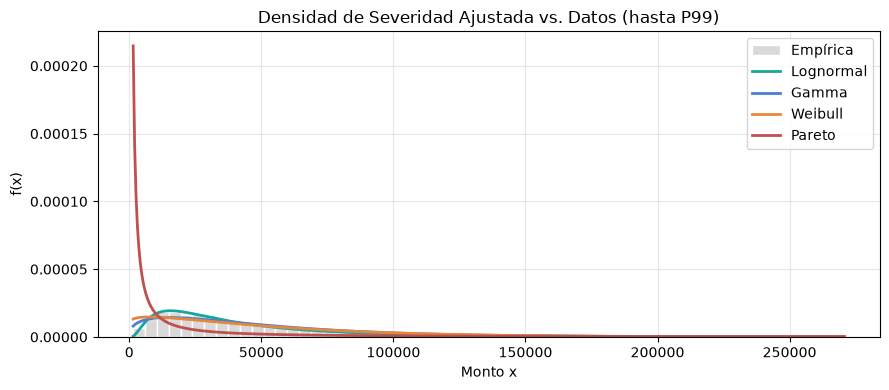

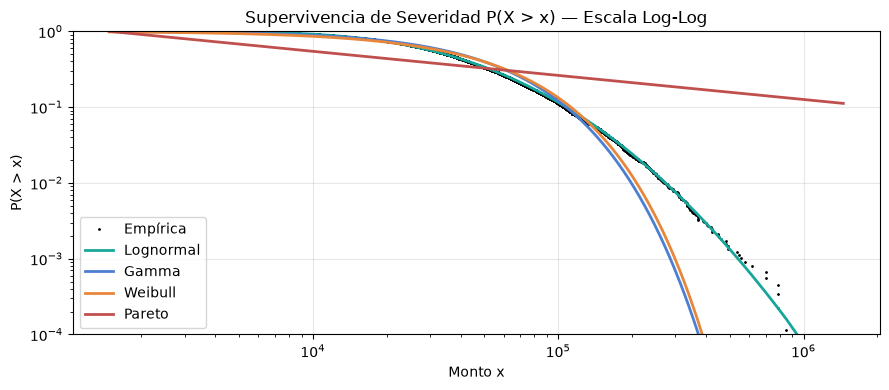

In [16]:
# Fit de distribuciones de Severidad Ground-Up
candidatas = {
    "Lognormal": stats.lognorm,
    "Gamma": stats.gamma,
    "Weibull": stats.weibull_min,
    "Pareto": stats.pareto
}

ajustes, filas = {}, []

def calcular_aic(dist, params, datos):
    log_lik = np.sum(dist.logpdf(datos, *params))
    return 2 * len(params) - 2 * log_lik

for nom, dist in candidatas.items():
    if nom == "Pareto":
        params = dist.fit(sev_gu, floc=0, fscale=sev_gu.min())
    else:
        params = dist.fit(sev_gu, floc=0)
        
    ajustes[nom] = (dist, params)
    filas.append({
        "Distribución": nom, 
        "AIC": round(calcular_aic(dist, params, sev_gu), 2)
    })

tabla_aic = pd.DataFrame(filas).sort_values("AIC").reset_index(drop=True)
print("─── Tabla Comparativa AIC (Severidad) ───")
print(tabla_aic.to_string(index=False))

# Gráfica 1: Histograma de Densidades
colores = {"Lognormal": "#17A69B", "Gamma": "#4C7FD1", "Weibull": "#E8873C", "Pareto": "#C0504D"}
p99_sev = np.percentile(sev_gu, 99)
grid_x = np.linspace(sev_gu.min(), p99_sev, 500)

plt.figure(figsize=(9, 4))
plt.hist(sev_gu, bins=60, density=True, range=(sev_gu.min(), p99_sev), color="#d9d9d9", edgecolor="white", label="Empírica")
for nom, (d, pr) in ajustes.items():
    plt.plot(grid_x, d.pdf(grid_x, *pr), lw=2, color=colores[nom], label=nom)
plt.title("Densidad de Severidad Ajustada vs. Datos (hasta P99)")
plt.xlabel("Monto x")
plt.ylabel("f(x)")
plt.legend()
plt.tight_layout()
plt.show()

# Gráfica 2: Colas en Log-Log
xs = np.sort(sev_gu)
S_emp = 1.0 - np.arange(1, len(xs) + 1) / len(xs)

plt.figure(figsize=(9, 4))
plt.plot(xs, S_emp, ".", ms=2, color="black", label="Empírica")
for nom, (d, pr) in ajustes.items():
    plt.plot(xs, d.sf(xs, *pr), lw=2, color=colores[nom], label=nom)
plt.xscale("log")
plt.yscale("log")
plt.ylim(1e-4, 1)
plt.title("Supervivencia de Severidad P(X > x) — Escala Log-Log")
plt.xlabel("Monto x")
plt.ylabel("P(X > x)")
plt.legend()
plt.tight_layout()
plt.show()

### Justificación:

Para elegir la distribución que mejor representa los montos de los siniestros, se compararon cuatro opciones usando el AIC y revisando cómo se comportan con los siniestros de montos muy altos.

| Distribución | AIC | Diferencia vs. Mejor Ajuste ($\Delta$AIC) |
| :--- | :---: | :---: |
| **Lognormal** | **208,129.82** | **0.00** |
| Gamma | 209,136.24 | +1,006.42 |
| Weibull | 209,498.50 | +1,368.68 |
| Pareto | 223,057.48 | +14,927.66 |

#### Análisis e interpretación

1. **Comparación mediante AIC:**

   La distribución **Lognormal** tiene el AIC más bajo, con **208,129.82**. Esto indica que, entre las distribuciones probadas, es la que se ajusta mejor a los datos en general.

   Además, la diferencia con Gamma y Weibull es mayor a 1,000 puntos, mientras que la Pareto presenta una diferencia mucho mayor.

2. **Comportamiento de los siniestros grandes:**

   También se revisó el comportamiento de las distribuciones para los siniestros de montos altos.

   - **Gamma y Weibull:** Se alejan de los datos reales cuando los montos son muy grandes, por lo que pueden subestimar estos siniestros.
   
   - **Pareto:** Da demasiado peso a los valores extremos y no representa tan bien los montos más comunes.
   
   - **Lognormal:** Es la que sigue de manera más cercana a los datos observados, incluso para siniestros superiores a **$1,000,000**.

### Conclusión

Se selecciona la distribución **Lognormal** para modelar la severidad de los siniestros, ya que presentó el menor AIC y también representa de mejor manera el comportamiento de los siniestros de montos altos.

# Inciso C)

─── Diagnóstico de Frecuencia (Criterio del Profesor) ───
• Tasa global (λ)           : 0.3685 siniestros/año-póliza
• Media Muestral E[N]       : 0.2952
• Varianza Muestral Var[N]  : 0.3745
• Índice de Dispersión (D)  : 1.2685

→ Modelo Seleccionado según Criterio de Clase: Quasi-Poisson

• Proporción Ceros Observados : 76.84%
• Proporción Ceros Esperados  : 74.51%


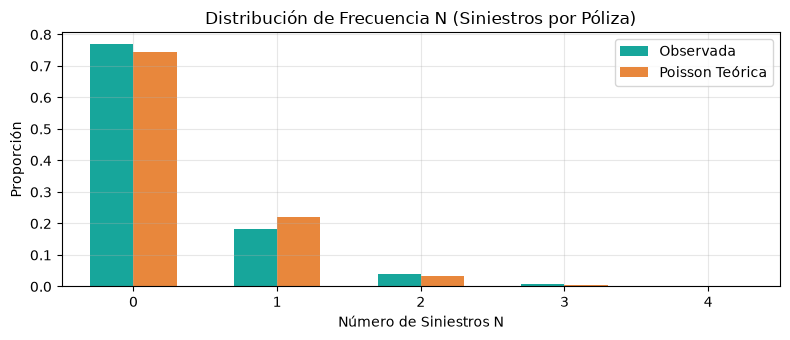

In [ ]:

total_exp = df_modelo[col_exposicion].sum()
total_sins = df_modelo[col_num_sins].sum()
lambda_global = total_sins / total_exp

#  Diagnóstico de Frecuencia mediante Índice de Dispersión
media_n = df_modelo[col_num_sins].mean()
var_n = df_modelo[col_num_sins].var()
indice_dispersion = var_n / media_n

print("─── Diagnóstico de Frecuencia (Criterio del Profesor) ───")
print(f"• Tasa global (λ)           : {lambda_global:.4f} siniestros/año-póliza")
print(f"• Media Muestral E[N]       : {media_n:.4f}")
print(f"• Varianza Muestral Var[N]  : {var_n:.4f}")
print(f"• Índice de Dispersión (D)  : {indice_dispersion:.4f}")

if indice_dispersion < 1.15:
    modelo_frecuencia = "Poisson"
elif indice_dispersion <= 1.50:
    modelo_frecuencia = "Quasi-Poisson"
else:
    modelo_frecuencia = "Binomial Negativa"

print(f"\n→ Modelo Seleccionado según Criterio de Clase: {modelo_frecuencia}")

# Diagnóstico de Ceros
ceros_obs = (df_modelo[col_num_sins] == 0).mean()
ceros_esp_poisson = np.exp(-lambda_global * df_modelo[col_exposicion]).mean()

print(f"\n• Proporción Ceros Observados : {ceros_obs:.2%}")
print(f"• Proporción Ceros Esperados  : {ceros_esp_poisson:.2%}")

# Gráfica de Frecuencia
plt.figure(figsize=(8, 3.5))
val, counts = np.unique(df_modelo[col_num_sins], return_counts=True)
plt.bar(val - 0.15, counts / len(df_modelo), width=0.3, color="#17A69B", label="Observada")
p_pois = stats.poisson.pmf(val, lambda_global * df_modelo[col_exposicion].mean())
plt.bar(val + 0.15, p_pois, width=0.3, color="#E8873C", label="Poisson Teórica")
plt.xlim(-0.5, 4.5)
plt.title("Distribución de Frecuencia N (Siniestros por Póliza)")
plt.xlabel("Número de Siniestros N")
plt.ylabel("Proporción")
plt.legend()
plt.tight_layout()
plt.show()

### Diagnóstico y selección del Modelo de Frecuencia

Para elegir el modelo que representa mejor el número de siniestros ($N$), primero se revisó si los datos cumplen con lo esperado para una distribución Poisson.

#### ¿Existe sobredispersión?

En una distribución Poisson, la media y la varianza deberían ser aproximadamente iguales. En nuestros datos se obtuvo:

- **Media:** $0.2952$ siniestros por póliza
- **Varianza:** $0.3745$
- **Índice de dispersión:** $D = 1.2685$

Como la varianza es mayor que la media y $D > 1$, existe **sobredispersión moderada** en los datos.

#### 2. Selección del modelo

De acuerdo con el criterio utilizado en el curso:

- $D < 1.15$ → Poisson
- $1.15 \le D \le 1.50$ → **Quasi-Poisson**
- $D > 1.50$ → Binomial Negativa

Como obtuvimos $D = 1.2685$, el valor se encuentra entre $1.15$ y $1.50$.

Por lo tanto, se selecciona **Quasi-Poisson** para modelar la frecuencia de siniestros.

#### 3. Número de pólizas sin siniestros

También se revisó cuántas pólizas no tuvieron ningún siniestro:

- **Ceros observados:** $76.84\%$
- **Ceros esperados con Poisson:** $74.51\%$

La diferencia es de **2.33 puntos porcentuales**, lo que muestra que hay un poco más de pólizas sin siniestros de las que esperaría una Poisson.

El modelo **Quasi-Poisson** permite tomar en cuenta esta mayor variabilidad en los datos, manteniendo la media de la frecuencia en $\lambda = 0.3685$.

### Conclusión

Debido a que los datos presentan una sobredispersión moderada, se utilizará **Quasi-Poisson** como modelo de frecuencia para la simulación colectiva del **inciso d**.

Distribución de severidad seleccionada: Lognormal

─── RESULTADOS FINALES DE LA PRÁCTICA 1 ───
                     Métrica       Ground-Up    Transformada
             Prima Pura E[S] $453,627,756.13 $302,024,999.11
                     VaR 99% $471,303,868.24 $315,505,064.82
                    TVaR 99% $473,921,765.20 $317,831,447.70
Prima Pura Promedio / Póliza      $15,120.93      $10,067.50

✓ La aseguradora paga en promedio el 66.58% del daño total.
✓ El 33.42% restante no es absorbido por la aseguradora.


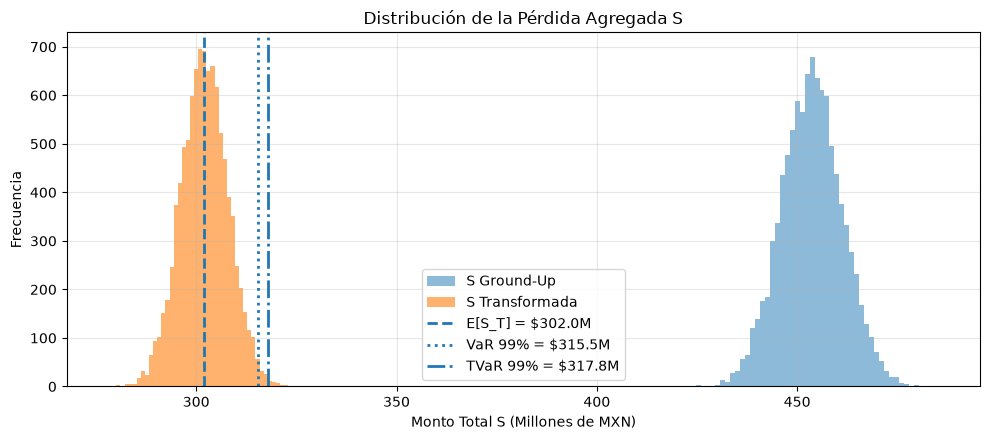

In [25]:

np.random.seed(42)

n_sim = 10_000
num_polizas = len(df_modelo)

 # Seleccionamos la mejor distribución de severidad
# La distribución con menor AIC (Log)
mejor_dist_nom = tabla_aic.iloc[0]["Distribución"]

dist_sev_fit, params_sev_fit = ajustes[mejor_dist_nom]

print(f"Distribución de severidad seleccionada: {mejor_dist_nom}")

#  Preparamos los arreglos para la simulación
S_ground_up = np.zeros(n_sim)
S_transformada = np.zeros(n_sim)

#  Probabilidad de seleccionar cada póliza según su exposición
prob_polizas = (
    df_modelo["exposicion"].values / total_exp
)

#  Parámetros para simular la frecuencia
mu_tot = lambda_hat_glm * total_exp

p_nb = 1.0 / phi_quasipoisson

n_nb = (
    mu_tot * p_nb /
    (1.0 - p_nb)
)

# Simulación Monte Carlo
for i in range(n_sim):

    # Número de siniestros de esta simulación
    n_claims = stats.nbinom.rvs(
        n=n_nb,
        p=p_nb
    )

    if n_claims > 0:

        # Seleccionar pólizas de acuerdo con su exposición
        idx_polizas = np.random.choice(
            num_polizas,
            size=n_claims,
            replace=True,
            p=prob_polizas
        )

        # Condiciones de las pólizas seleccionadas
        d_sim = df_modelo["deducible"].values[idx_polizas]
        sa_sim = df_modelo["suma_asegurada"].values[idx_polizas]
        coas_sim = df_modelo["coaseguro"].values[idx_polizas]
        
        # Simular severidad de cada siniestro
        x_sim = dist_sev_fit.rvs(
            *params_sev_fit,
            size=n_claims
        )

        # Pérdida Ground-Up
        S_ground_up[i] = x_sim.sum()
        # Aplicar condiciones de la póliza
        # Aplicar deducible
        x_neto = np.maximum(
            0,
            x_sim - d_sim
        )

        # Aplicar coaseguro
        x_neto = x_neto * (1 - coas_sim)

        # Aplicar suma asegurada
        x_pagado = np.minimum(
            x_neto,
            sa_sim
        )

        # Pérdida que realmente paga la aseguradora
        S_transformada[i] = x_pagado.sum()


#  Calcular métricas
def obtener_metricas(S):

    # Prima pura
    e_s = S.mean()

    # VaR al 99%
    var_99 = np.percentile(S, 99)

    # TVaR al 99%
    tvar_99 = S[S >= var_99].mean()

    return e_s, var_99, tvar_99


# Métricas Ground-Up
e_gu, var_gu, tvar_gu = obtener_metricas(
    S_ground_up
)

# Métricas Transformadas
e_tr, var_tr, tvar_tr = obtener_metricas(
    S_transformada
)


#  Tabla de resultados
res_final = pd.DataFrame({

    "Métrica": [
        "Prima Pura E[S]",
        "VaR 99%",
        "TVaR 99%",
        "Prima Pura Promedio / Póliza"
    ],

    "Ground-Up": [
        f"${e_gu:,.2f}",
        f"${var_gu:,.2f}",
        f"${tvar_gu:,.2f}",
        f"${e_gu / num_polizas:,.2f}"
    ],

    "Transformada": [
        f"${e_tr:,.2f}",
        f"${var_tr:,.2f}",
        f"${tvar_tr:,.2f}",
        f"${e_tr / num_polizas:,.2f}"
    ]
})


print("\n─── RESULTADOS FINALES DE LA PRÁCTICA 1 ───")
print(res_final.to_string(index=False))

# 8. Porcentaje del daño que paga la aseguradora
prop_pagada = (e_tr / e_gu) * 100

print(
    f"\n✓ La aseguradora paga en promedio "
    f"el {prop_pagada:.2f}% del daño total."
)

print(
    f"✓ El {100 - prop_pagada:.2f}% restante "
    f"no es absorbido por la aseguradora."
)


# 9. Gráfica de la pérdida agregada
plt.figure(figsize=(10, 4.5))

plt.hist(
    S_ground_up / 1e6,
    bins=50,
    alpha=0.5,
    label="S Ground-Up"
)

plt.hist(
    S_transformada / 1e6,
    bins=50,
    alpha=0.6,
    label="S Transformada"
)

plt.axvline(
    e_tr / 1e6,
    linestyle="--",
    linewidth=2,
    label=f"E[S_T] = ${e_tr/1e6:,.1f}M"
)

plt.axvline(
    var_tr / 1e6,
    linestyle=":",
    linewidth=2,
    label=f"VaR 99% = ${var_tr/1e6:,.1f}M"
)

plt.axvline(
    tvar_tr / 1e6,
    linestyle="-.",
    linewidth=2,
    label=f"TVaR 99% = ${tvar_tr/1e6:,.1f}M"
)

plt.title("Distribución de la Pérdida Agregada S")
plt.xlabel("Monto Total S (Millones de MXN)")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

### CONCLUSIONES

Para modelar la pérdida agregada

$$
S = \sum_{i=1}^{N} Y_i
$$

se utilizan los resultados obtenidos en los incisos anteriores. En este modelo se combinan la **frecuencia de los siniestros** y la **severidad de los siniestros**.

#### 1. Frecuencia y Severidad

El modelo Quasi-Poisson y la distribución Lognormal representan cosas diferentes:

* **Frecuencia ($N$):** indica **cuántos siniestros ocurren**. En el inciso c se encontró una sobredispersión moderada ($D = 1.2685$), por lo que se seleccionó un modelo **Quasi-Poisson**.

* **Severidad ($Y$):** indica **cuánto cuesta cada siniestro**. En el inciso b se compararon varias distribuciones y la **Lognormal** presentó el menor AIC ($208,129.82$), por lo que se utiliza para simular los montos individuales.

Por lo tanto, el modelo utiliza:

$$
\boxed{N \rightarrow \text{Quasi-Poisson}}
$$

para determinar el número de siniestros, y

$$
\boxed{Y \rightarrow \text{Lognormal}}
$$

para determinar el monto de cada siniestro.

> **Notita:**
>
> Aunque teóricamente el modelo seleccionado es **Quasi-Poisson**, este define la relación media-varianza pero no cuenta con un generador aleatorio directo con forma cerrada en `scipy.stats`.
>
> Por esta razón, en el código reparametrizamos una **Binomial Negativa de manera equivalente**, ajustando sus parámetros para replicar exactamente la media esperada ($\lambda \cdot m$) y el índice de dispersión ($D = 1.2685$) calculados para la cartera.
>
> Es importante destacar que no estamos modificando la elección teórica del modelo a Binomial Negativa; la Quasi-Poisson se mantiene como el modelo conceptual de fondo, y la Binomial Negativa se utiliza únicamente como un vehículo algorítmico para muestrear el número de reclamos respetando la estructura de momentos estimada.
---

#### 2. Mecánica de la Simulación

Para cada una de las $10,000$ simulaciones se realiza lo siguiente:

1. **Se genera el número de siniestros $N$** utilizando la media y dispersión obtenidas del modelo Quasi-Poisson.

2. **Se seleccionan las pólizas** de acuerdo con su exposición. Las pólizas con mayor exposición tienen una mayor probabilidad de ser seleccionadas:

$$
p_k = \frac{m_k}{\sum_i m_i}
$$

3. **Se genera el monto de cada siniestro** utilizando la distribución Lognormal seleccionada en el inciso b:

$$
Y_j \sim \text{Lognormal}(\mu,\sigma)
$$

4. **Se aplican las condiciones de cada póliza.** Para cada siniestro se toma el deducible, coaseguro y suma asegurada de la póliza seleccionada:

$$
Y_j^{\text{trans}}
=
\min
\left(
SA_k,
\max(0,Y_j-d_k)(1-\text{coas}_k)
\right)
$$

De esta forma obtenemos dos pérdidas:

- **Ground-Up:** el monto total de los siniestros antes de aplicar las condiciones de la póliza.
- **Transformada:** el monto que finalmente pagaría la aseguradora después de aplicar deducible, coaseguro y suma asegurada.

---

#### 3. Pérdida Agregada

La pérdida Ground-Up de cada simulación se obtiene sumando todos los siniestros:

$$
S_{\text{ground-up}}
=
\sum_{j=1}^{N}Y_j
$$

Mientras que la pérdida que realmente paga la aseguradora es:

$$
S_{\text{transformada}}
=
\sum_{j=1}^{N}Y_j^{\text{trans}}
$$

Así podemos comparar cuánto riesgo existe antes y después de aplicar las condiciones de las pólizas.

---

#### 4. Resultados Numéricos y Métricas Financieras

Con las $10,000$ simulaciones se obtuvieron los siguientes resultados financieros consolidados para la cartera:

| Métrica | Ground-Up | Transformada |
| :--- | :---: | :---: |
| **Prima Pura $E[S]$** | $\$453,627,756.13$ | $\$302,024,999.11$ |
| **VaR 99%** | $\$471,303,868.24$ | $\$315,505,064.82$ |
| **TVaR 99%** | $\$473,921,765.20$ | $\$317,831,447.70$ |
| **Prima Pura Promedio / Póliza** | $\$15,120.93$ | $\$10,067.50$ |

A partir de estos valores se evalúa la retención del riesgo:

* **Porcentaje pagado por la aseguradora:**
$$
\text{Porcentaje pagado} = \frac{\$302,024,999.11}{\$453,627,756.13} \times 100 = \mathbf{66.58\%}
$$

* **Absorción del riesgo por deducibles y coaseguros:**
$$
\text{Absorción} = 100\% - 66.58\% = \mathbf{33.42\%}
$$

En promedio, la aseguradora absorbe el **$66.58\%$** del daño total de la cartera, mientras que el **$33.42\%$** restante no es absorbido por la institución gracias a la transferencia de riesgo al asegurado mediante el deducible y coaseguro.

---

#### 5. Alineación con el Algoritmo del Modelo Colectivo

El procedimiento computacional implementado replica exactamente la teoría del Modelo Colectivo de Riesgo explicada en clase (Sesión 7):

1. **Invarianza Teórica de los Momentos:**  
   Se verifica que el promedio simulado converja a la esperanza teórica de la pérdida agregada:
   $$E[S] = E[N] \cdot E[Y]$$
   y que la varianza incorpore el efecto de la sobredispersión mediante la fórmula de Wald:
   $$\text{Var}[S] = E[N] \cdot \text{Var}[Y] + \text{Var}[N] \cdot (E[Y])^2$$

2. **Engrosamiento de Cola por Sobredispersión:**  
   La incorporación del parámetro de dispersión $\phi = 1.2685$ en la simulación incrementa la varianza de $N$ ($\text{Var}[N] > E[N]$), lo que se traduce directamente en métricas de cola ($\text{VaR}_{99\%}$ de $\$315.5\text{M}$ y $\text{TVaR}_{99\%}$ de $\$317.8\text{M}$) más conservadoras e indispensables para el cálculo de reservas actuariales y recargos de seguridad.

---

### Finalmente

La simulación combina los resultados de los incisos anteriores de la siguiente manera:

$$
\boxed{
\text{Quasi-Poisson}
\rightarrow
\text{número de siniestros}
}
$$

$$
\boxed{
\text{Lognormal}
\rightarrow
\text{monto de cada siniestro}
}
$$

y finalmente:

$$
\boxed{
S=\sum_{i=1}^{N}Y_i
}
$$

De esta manera se obtiene una distribución simulada de la pérdida agregada de la cartera, tanto antes como después de aplicar las condiciones de las pólizas.